In [11]:
import tqdm
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# # import A03simple_example_template.py with reload
# %load_ext autoreload
# %autoreload 2
# from A03simple_example_template import sample_reverse

In [4]:
# generate a dataset of 1D data from a mixture of two Gaussians
# this is a simple example, but you can use any distribution
data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1, 2])),
    torch.distributions.Normal(torch.tensor([-4., 4.]), torch.tensor([1., 1.]))
)

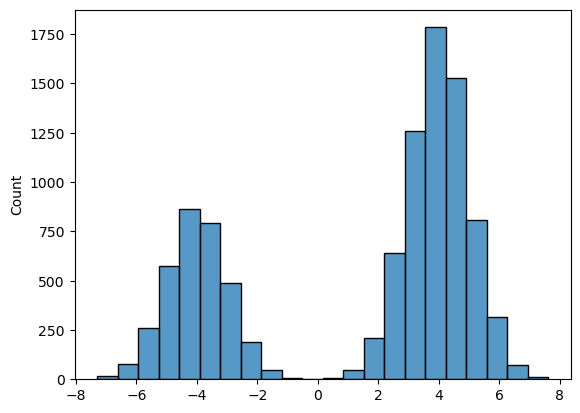

In [6]:
dataset = data_distribution.sample(torch.Size([10000]))  # create training data set
dataset_validation = data_distribution.sample(torch.Size([1000])) # create validation data set
fig, ax = plt.subplots(1, 1)
sns.histplot(dataset)
plt.show()

In [ ]:
# we will keep these parameters fixed throughout
# these parameters should give you an acceptable result
# but feel free to play with them
TIME_STEPS = 250
BETA = torch.tensor(0.02)
N_EPOCHS = 1000
BATCH_SIZE = 64
LEARNING_RATE = 0.8e-4
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [9]:
# define the neural network that predicts the amount of noise that was
# added to the data
# the network should have two inputs (the current data and the time step)
# and one output (the predicted noise)

g = torch.nn.Sequential(
    torch.nn.Linear(2, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 1)
)

In [ ]:
def loss(g, x0, t, noise, beta):
    alphaBar = (1 - beta) ** (t + 1)

    xt = torch.sqrt(alphaBar) * x0 + torch.sqrt(1 - alphaBar) * noise

    predicted_noise = g(xt, t)

    return torch.nn.functional.mse_loss(predicted_noise, noise)

In [ ]:
model = g.to("cuda")
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [ ]:



epochs = tqdm(range(N_EPOCHS))  # this makes a nice progress bar

train_losses = []
validation_losses = []

for e in epochs: # loop over epochs
    total_train_loss = 0.0
    g.train()
    # loop through batches of the dataset, reshuffling it each epoch
    indices = torch.randperm(dataset.shape[0])
    shuffled_dataset = dataset[indices]
    for i in range(0, shuffled_dataset.shape[0] - BATCH_SIZE, BATCH_SIZE):
        # sample a batch of data
        x0 = shuffled_dataset[i:i + BATCH_SIZE]
        
        # here, implement algorithm 1 of the DDPM paper (https://arxiv.org/abs/2006.11239)
        t = torch.randint(0, TIME_STEPS, (BATCH_SIZE,)).to(device)  # sample random time steps
        noise = torch.randn_like(x0).to(device)  # sample noise

        # compute the loss
        optimizer.zero_grad()

        l = loss(g, x0.to(device), t, noise, BETA.to(device))
        l.backward()
        optimizer.step()

        total_train_loss += l.item()

        if (i + 1) % (BATCH_SIZE * 10) == 0:  # print every 10 batches
            epochs.set_description(f"Epoch {e+1}/{N_EPOCHS}, Loss: {total_train_loss / (i + 1):.4f}")

    sys.stdout.write("\n")

    print(f"Epoch {e+1}/{N_EPOCHS}, Loss: {total_train_loss / (len(shuffled_dataset) // BATCH_SIZE):.4f}")

    train_losses.append(total_train_loss / (len(shuffled_dataset) // BATCH_SIZE))

    # compute the loss on the validation set
    g.eval()
    total_validation_loss = 0.0

    with torch.no_grad():
        for i in range(0, dataset_validation.shape[0] - BATCH_SIZE, BATCH_SIZE):
            x0 = dataset_validation[i:i + BATCH_SIZE]
            t = torch.randint(0, TIME_STEPS, (BATCH_SIZE,)).to(device)  # sample random time steps
            noise = torch.randn_like(x0).to(device)  # sample noise
            # compute the validation loss
            l = loss(g, x0.to(device), t, noise, BETA.to(device))
            total_validation_loss += l.item()
    print(f"Validation Loss: {total_validation_loss / (len(dataset_validation) // BATCH_SIZE):.4f}")

    validation_losses.append(total_validation_loss / (len(dataset_validation) // BATCH_SIZE))

In [ ]:
def sample_reverse(g, count):
    """
    Sample from the model by applying the reverse diffusion process

    Here, implement algorithm 2 of the DDPM paper (https://arxiv.org/abs/2006.11239)

    Parameters
    ----------
    g : torch.nn.Module
        The neural network that predicts the noise added to the data
    count : int
        The number of samples to generate in parallel

    Returns
    -------
    x : torch.Tensor
        The final sample from the model
    """
    
    g.eval()